In [1]:
import pandas as pd 
import numpy as np
from numpy.linalg import svd, eig
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.6f}".format

In [2]:
# Read excel in data frame using panda
df = pd.read_csv('data6.csv')

# df = df.iloc[:,1:]

# Convert a data frame to a Numpy array 
A = df.values
print("A shape:", A.shape)

# Standardize the data (Z-score normalization)
means = np.mean(A, axis=0)
stdevs = np.std(A, axis=0)
cA = (A - means) / stdevs
print("\nStandardized Data (first 3 rows):\n", cA[:3])

# Number of principal components to consider
max_components = min(cA.shape) - 1  # Typically min(n_samples, n_features) - 1

A shape: (5000, 96)

Standardized Data (first 3 rows):
 [[-1.02449057e+00 -2.19371144e-01 -4.94746850e-01  4.43211391e-01
   4.38232461e-02 -4.21949972e-01 -4.90376609e-02 -1.62097946e+00
  -5.77902250e-01  2.74942906e-01 -1.46116873e+00 -2.34078103e-01
  -1.34712611e+00 -7.02701804e-01 -1.20226022e+00  1.44136642e-01
  -1.36520511e-01 -7.24738860e-01 -4.89380170e-02 -2.65433305e-02
   1.24052193e+00 -9.07583125e-02 -8.12308274e-01 -1.35670050e+00
  -8.44339857e-01 -7.32479118e-01 -2.69576827e-01  9.56180230e-02
   4.95112108e-01 -9.67079782e-01 -5.38161230e-01 -8.60248247e-02
   1.78102540e-01  2.23009224e-01 -7.29199078e-01 -1.10527703e-01
  -1.36562829e+00 -6.99229578e-01 -1.39949946e+00 -9.93397139e-01
   1.05821321e-01 -7.82251714e-01 -9.57733403e-01 -1.71010945e-02
  -1.00235296e+00 -2.77076713e-01  3.15393910e-01 -5.14171027e-01
  -1.25833661e-01  5.02919272e-01  6.29438973e-01  1.77205646e-01
  -2.09754634e-01 -1.20508820e+00 -1.37206139e+00 -3.11449683e-01
  -1.41066607e-01  1

In [3]:
### PCA using SVD
# -------------------------------
# Perform SVD on standardized data
U, S, V_T = svd(cA, full_matrices=False)
print("SVD Results:")
print("U shape:", U.shape)
print("S shape:", S.shape)
print("V_T shape:", V_T.shape)

# Calculate explained variance
explained_variance_svd = (S ** 2) / (S ** 2).sum() * 100
cumulative_variance_svd = np.cumsum(explained_variance_svd)

# Determine number of components to capture desired variance (e.g., 85%)
desired_variance = 85
n_components_svd = np.argmax(cumulative_variance_svd >= desired_variance) + 1
print(f"\nSVD: Number of components to capture at least {desired_variance}% variance: {n_components_svd}")

# Extract principal components (loadings)
loadings_svd = V_T[:n_components_svd].T
print("\nSVD Loadings (first few):\n", loadings_svd[:5])

SVD Results:
U shape: (5000, 96)
S shape: (96,)
V_T shape: (96, 96)

SVD: Number of components to capture at least 85% variance: 11

SVD Loadings (first few):
 [[ 0.08034928 -0.19116633  0.04107276 -0.05759589  0.17262332 -0.04073468
   0.02483289 -0.02348844  0.01726942 -0.01605158  0.09887993]
 [ 0.12486607  0.08370493  0.05928907  0.10818658  0.02908901 -0.03966236
   0.01658101 -0.02113255  0.05404849 -0.04464918  0.01222021]
 [ 0.11319957  0.09087651  0.07423812 -0.02508715  0.07695394 -0.00761916
  -0.05282025 -0.00858273 -0.08988847  0.0471174   0.07176542]
 [ 0.09314339 -0.09332442  0.00077482  0.02547571 -0.25333986  0.14614315
   0.16184036 -0.12709693 -0.11239911 -0.02087053 -0.02211834]
 [ 0.12046721  0.10602273  0.07561465  0.10137609  0.01392499 -0.03555497
   0.01226496 -0.01153283  0.05083406 -0.02508814  0.01183754]]


In [4]:
# Create summary table for PCA computed via SVD
# Includes singular values, variance explained by each PC, and cumulative variance
svd_summary = pd.DataFrame({
    "PC": np.arange(1, len(explained_variance_svd)+1),
    "Singular Value": S,
    "Explained Variance (%)": explained_variance_svd,
    "Cumulative Variance (%)": cumulative_variance_svd
})

# Display first 10 principal components for inspection
display(svd_summary.head(10))

,PC,Singular Value,Explained Variance (%),Cumulative Variance (%)
0,1,519.235343,56.167780,56.167780
1,2,242.873927,12.289113,68.456893
2,3,153.763537,4.925672,73.382565
3,4,120.897874,3.045062,76.427627
4,5,103.723410,2.241364,78.668990
5,6,86.932673,1.574435,80.243426
6,7,81.020260,1.367559,81.610984
7,8,75.966289,1.202266,82.813251
8,9,73.164223,1.115209,83.928460
9,10,68.318779,0.972387,84.900846


In [5]:
# Create a DataFrame for SVD loadings
loading_df_svd = pd.DataFrame(
    loadings_svd,
    columns=[f'PC{i+1}' for i in range(n_components_svd)],
    index=df.columns
)

print("SVD Loadings:")
display(loading_df_svd)

# Calculate scores
scores_svd = U[:, :n_components_svd] * S[:n_components_svd]
print("\nSVD Scores shape:", scores_svd.shape)

SVD Loadings:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
Measurement1,0.080349,-0.191166,0.041073,-0.057596,0.172623,-0.040735,0.024833,-0.023488,0.017269,-0.016052,0.098880
Measurement2,0.124866,0.083705,0.059289,0.108187,0.029089,-0.039662,0.016581,-0.021133,0.054048,-0.044649,0.012220
Measurement3,0.113200,0.090877,0.074238,-0.025087,0.076954,-0.007619,-0.052820,-0.008583,-0.089888,0.047117,0.071765
Measurement4,0.093143,-0.093324,0.000775,0.025476,-0.253340,0.146143,0.161840,-0.127097,-0.112399,-0.020871,-0.022118
Measurement5,0.120467,0.106023,0.075615,0.101376,0.013925,-0.035555,0.012265,-0.011533,0.050834,-0.025088,0.011838
...,...,...,...,...,...,...,...,...,...,...,...
Measurement92,0.119432,-0.028494,-0.122960,0.013671,-0.038768,0.104985,0.089831,-0.017612,0.011321,-0.032261,0.041051
Measurement93,0.112747,0.041599,0.072449,0.214695,0.010433,-0.079445,0.069973,-0.049480,0.144191,-0.122939,-0.067426
Measurement94,0.019880,-0.075452,-0.010410,-0.046392,0.363282,-0.148390,0.275060,0.334196,0.134181,0.120411,0.040594
Measurement95,0.120730,0.092191,0.019189,0.107415,0.002847,-0.012395,-0.008084,-0.029172,0.009204,0.005701,-0.004200



SVD Scores shape: (5000, 11)


In [6]:
### PCA using Eigen Decomposition
# --------------------------------
# Compute covariance matrix
cov_matrix = np.cov(cA, rowvar=False)
print("Covariance Matrix shape:", cov_matrix.shape)

# Perform Eigen Decomposition
e_values, e_vectors = eig(cov_matrix)
print("\nEigen Decomposition Results:")
print("Eigenvalues:", e_values)
print("Eigenvectors shape:", e_vectors.shape)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(e_values)[::-1]
e_values_sorted = e_values[sorted_indices]
e_vectors_sorted = e_vectors[:, sorted_indices]

# Calculate explained variance
explained_variance_eig = (e_values_sorted.real) / (e_values_sorted.real.sum()) * 100
cumulative_variance_eig = np.cumsum(explained_variance_eig)

# Determine number of components to capture desired variance (e.g., 85%)
n_components_eig = np.argmax(cumulative_variance_eig >= desired_variance) + 1
print(f"\nEigen Decomposition: Number of components to capture at least {desired_variance}% variance: {n_components_eig}")

# Extract principal components (loadings)
loadings_eig = e_vectors_sorted[:, :n_components_eig]
print("\nEigen Decomposition Loadings (first few):\n", loadings_eig[:5])

Covariance Matrix shape: (96, 96)

Eigen Decomposition Results:
Eigenvalues: [5.39318548e+01 1.17999088e+01 4.72959098e+00 2.92384397e+00
 2.15213959e+00 1.51176027e+00 1.31311913e+00 1.15440631e+00
 1.07081486e+00 9.33677849e-01 8.92671852e-01 8.13593976e-01
 7.09366529e-01 6.23105206e-01 6.10108789e-01 5.70568699e-01
 5.46953741e-01 5.35112145e-01 5.12088074e-01 4.88006895e-01
 4.53908786e-01 3.84596435e-01 4.07557864e-01 4.03314698e-01
 3.56381336e-01 3.41947735e-01 3.05976405e-01 2.93124115e-01
 2.64608492e-01 2.63060844e-01 2.51971277e-01 2.38854189e-01
 2.19170164e-01 2.02795720e-01 1.92415715e-01 1.81732262e-01
 1.79336581e-01 1.74813570e-01 1.58213038e-01 1.57017629e-01
 1.36527587e-01 1.39497425e-01 1.28327018e-01 1.20452860e-01
 1.19904113e-01 1.11355812e-01 1.04021502e-01 1.01962495e-01
 9.83671083e-02 9.48642992e-02 9.22513850e-02 8.27027664e-02
 8.62918994e-02 7.84436794e-02 7.11188579e-02 5.84039402e-02
 6.63767403e-02 6.58391646e-02 6.17749364e-02 6.22024130e-02
 5.35394

In [7]:
# Create equivalent PCA summary table using eigen decomposition of the covariance matrix
eig_summary = pd.DataFrame({
    "PC": np.arange(1, len(explained_variance_eig)+1),
    "Eigenvalue": e_values,
    "Explained Variance (%)": explained_variance_eig,
    "Cumulative Variance (%)": cumulative_variance_eig
})

# Display first 10 components
display(eig_summary.head(10))

,PC,Eigenvalue,Explained Variance (%),Cumulative Variance (%)
0,1,53.931855,56.167780,56.167780
1,2,11.799909,12.289113,68.456893
2,3,4.729591,4.925672,73.382565
3,4,2.923844,3.045062,76.427627
4,5,2.152140,2.241364,78.668990
5,6,1.511760,1.574435,80.243426
6,7,1.313119,1.367559,81.610984
7,8,1.154406,1.202266,82.813251
8,9,1.070815,1.115209,83.928460
9,10,0.933678,0.972387,84.900846


In [8]:
# Create a DataFrame for Eigen Decomposition loadings
loading_df_eig = pd.DataFrame(
    loadings_eig,
    columns=[f'PC{i+1}' for i in range(n_components_eig)],
    index=df.columns
)
print("Eigen Decomposition Loadings:")
display(loading_df_eig)

# Calculate scores
scores_eig = np.dot(cA, loadings_eig)
print("\nEigen Decomposition Scores shape:", scores_eig.shape)

Eigen Decomposition Loadings:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
Measurement1,0.080349,0.191166,-0.041073,0.057596,-0.172623,-0.040735,0.024833,-0.023488,-0.017269,-0.016052,0.098880
Measurement2,0.124866,-0.083705,-0.059289,-0.108187,-0.029089,-0.039662,0.016581,-0.021133,-0.054048,-0.044649,0.012220
Measurement3,0.113200,-0.090877,-0.074238,0.025087,-0.076954,-0.007619,-0.052820,-0.008583,0.089888,0.047117,0.071765
Measurement4,0.093143,0.093324,-0.000775,-0.025476,0.253340,0.146143,0.161840,-0.127097,0.112399,-0.020871,-0.022118
Measurement5,0.120467,-0.106023,-0.075615,-0.101376,-0.013925,-0.035555,0.012265,-0.011533,-0.050834,-0.025088,0.011838
...,...,...,...,...,...,...,...,...,...,...,...
Measurement92,0.119432,0.028494,0.122960,-0.013671,0.038768,0.104985,0.089831,-0.017612,-0.011321,-0.032261,0.041051
Measurement93,0.112747,-0.041599,-0.072449,-0.214695,-0.010433,-0.079445,0.069973,-0.049480,-0.144191,-0.122939,-0.067426
Measurement94,0.019880,0.075452,0.010410,0.046392,-0.363282,-0.148390,0.275060,0.334196,-0.134181,0.120411,0.040594
Measurement95,0.120730,-0.092191,-0.019189,-0.107415,-0.002847,-0.012395,-0.008084,-0.029172,-0.009204,0.005701,-0.004200



Eigen Decomposition Scores shape: (5000, 11)


In [9]:
### Comparison of Loadings from SVD and Eigen Decomposition
# ----------------------------------------------------------
# Align SVD loadings with Eigen loadings
# (PCA directions are sign-ambiguous, so components may differ by ±1)
for i in range(n_components_svd):
    if np.sum(loadings_svd[:, i]) < 0:
        loadings_svd[:, i] = -loadings_svd[:, i]
        scores_svd[:, i] = -scores_svd[:, i]

# Verify if loadings are similar
loadings_difference = np.abs(loadings_svd - loadings_eig)
loadings_diff_df = pd.DataFrame(
    loadings_difference,
    columns=[f"PC{i+1}" for i in range(loadings_difference.shape[1])],
    index=df.columns
)

print("Difference between SVD and Eigen Decomposition loadings (should be near zero):")
display(loadings_diff_df.head(10))


# Loading comparison for first 4 principal components
loading_diff = pd.DataFrame(
    np.abs(loadings_svd[:, :4] - loadings_eig[:, :4]),
    columns=[f'PC{i+1}' for i in range(4)],
    index=df.columns
)

print("Max difference per PC:")
max_diff = loading_diff.max()
for pc, val in max_diff.items():
    print(f"{pc}: {val}")

Difference between SVD and Eigen Decomposition loadings (should be near zero):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
Measurement1,0.000000,0.000000,0.082146,0.115192,0.000000,0.081469,0.000000,0.000000,0.000000,0.000000,0.197760
Measurement2,0.000000,0.000000,0.118578,0.216373,0.000000,0.079325,0.000000,0.000000,0.000000,0.000000,0.024440
Measurement3,0.000000,0.000000,0.148476,0.050174,0.000000,0.015238,0.000000,0.000000,0.000000,0.000000,0.143531
Measurement4,0.000000,0.000000,0.001550,0.050951,0.000000,0.292286,0.000000,0.000000,0.000000,0.000000,0.044237
Measurement5,0.000000,0.000000,0.151229,0.202752,0.000000,0.071110,0.000000,0.000000,0.000000,0.000000,0.023675
Measurement6,0.000000,0.000000,0.212196,0.026453,0.000000,0.172315,0.000000,0.000000,0.000000,0.000000,0.100640
Measurement7,0.000000,0.000000,0.057537,0.141709,0.000000,0.090077,0.000000,0.000000,0.000000,0.000000,0.206173
Measurement8,0.000000,0.000000,0.275240,0.005608,0.000000,0.205343,0.000000,0.000000,0.000000,0.000000,0.141927
Measurement9,0.000000,0.000000,0.144456,0.155443,0.000000,0.214666,0.000000,0.000000,0.000000,0.000000,0.029619
Measurement10,0.000000,0.000000,0.335905,0.274573,0.000000,0.170446,0.000000,0.000000,0.000000,0.000000,0.364035


Max difference per PC:
PC1: 1.1796119636642288e-15
PC2: 3.913536161803677e-15
PC3: 0.5646634925018772
PC4: 0.8537901901066203


In [10]:
# Function to determine how many PCs are required to reach specified
# cumulative variance thresholds (e.g. 75%, 85%)
def pcs_for_variance(cumulative_variance, thresholds=[75, 85]):
    results = {}
    for t in thresholds:
        pc = np.argmax(cumulative_variance >= t) + 1
        results[t] = pc
    return results

In [11]:
# Visualization
# ----------------

# Scree Plot Configuration
# -----------------------------

# Define maximum number of PCs to plot as bars in the scree plot
max_plot_pc = 12  # Adjust this value as needed

# Ensure we do not exceed the total number of PCs available
total_pcs = len(explained_variance_svd)
max_plot_pc = min(max_plot_pc, total_pcs)

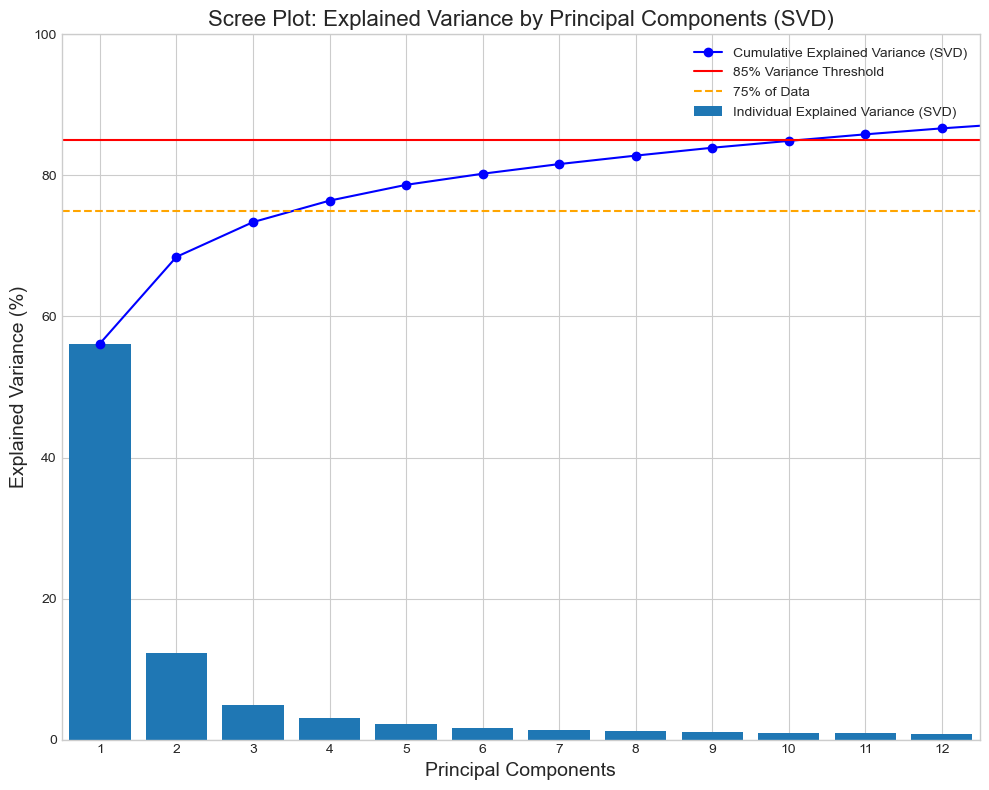

SVD Results
4 PCs explain 75% of variance
11 PCs explain 85% of variance


In [12]:
# Explained Variance Plot for SVD
# -------------------------------------

plt.figure(figsize=(10, 8))

# Plot Individual Explained Variance as bars up to max_plot_pc
plt.bar(range(1, max_plot_pc + 1), explained_variance_svd[:max_plot_pc], 
        align='center', label='Individual Explained Variance (SVD)')

# Plot Cumulative Explained Variance as a line for all PCs
plt.plot(range(1, total_pcs + 1), cumulative_variance_svd, 
         marker='o', linestyle='-', color='b', label='Cumulative Explained Variance (SVD)')

# Highlight the desired variance threshold
plt.axhline(y=desired_variance, color='r', linestyle='-', 
            label=f'{desired_variance}% Variance Threshold')

plt.axhline(y=75, color='orange', linestyle='--', label='75% of Data')

# Adjust x-axis to include padding on either side of the first and last bars
padding = 0.5  # Number of extra components to display as padding
plt.xlim(0 + padding, max_plot_pc + padding)

# Set x-axis ticks to include all PCs up to max_plot_pc
plt.xticks(range(1, max_plot_pc + 1))

# Set y-axis limits
plt.ylim(0, 100)

# Labels and Title
plt.xlabel('Principal Components', fontsize=14)
plt.ylabel('Explained Variance (%)', fontsize=14)
plt.title('Scree Plot: Explained Variance by Principal Components (SVD)', fontsize=16)

# Legend
plt.legend(loc='best')

# Enhance Layout
plt.tight_layout()

# Show Plot
plt.show()

# Apply the threshold analysis to the SVD PCA results
svd_pc_results = pcs_for_variance(cumulative_variance_svd)
print("SVD Results")
for k,v in svd_pc_results.items():
    print(f"{v} PCs explain {k}% of variance")

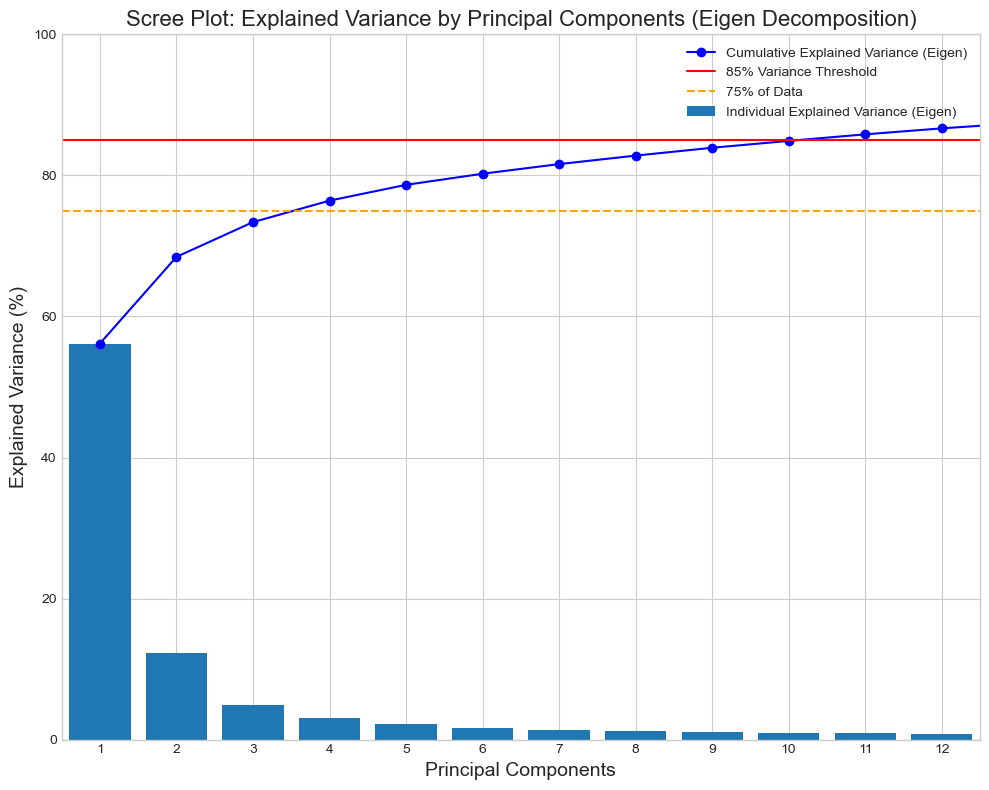


Eigen Results
4 PCs explain 75% of variance
11 PCs explain 85% of variance


In [13]:
# Explained Variance Plot for Eigen Decomposition
# -----------------------------------------------------

plt.figure(figsize=(10, 8))

# Plot Individual Explained Variance as bars up to max_plot_pc
plt.bar(range(1, max_plot_pc + 1), explained_variance_eig[:max_plot_pc],
        align='center', label='Individual Explained Variance (Eigen)')

# Plot Cumulative Explained Variance as a line for all PCs
plt.plot(range(1, total_pcs + 1), cumulative_variance_eig, 
         marker='o', linestyle='-', color='b', label='Cumulative Explained Variance (Eigen)')

# Highlight the desired variance threshold
plt.axhline(y=desired_variance, color='r', linestyle='-', 
            label=f'{desired_variance}% Variance Threshold')

plt.axhline(y=75, color='orange', linestyle='--', label='75% of Data')

# Adjust x-axis to include padding on either side of the first and last bars
padding = 0.5  # Number of extra components to display as padding
plt.xlim(0 + padding, max_plot_pc + padding)

# Set x-axis ticks to include all PCs up to max_plot_pc
plt.xticks(range(1, max_plot_pc + 1))

# Set y-axis limits
plt.ylim(0, 100)

# Labels and Title
plt.xlabel('Principal Components', fontsize=14)
plt.ylabel('Explained Variance (%)', fontsize=14)
plt.title('Scree Plot: Explained Variance by Principal Components (Eigen Decomposition)', fontsize=16)

# Legend
plt.legend(loc='best')

# Enhance Layout
plt.tight_layout()

# Show Plot
plt.show()

# Apply the threshold analysis to the Eigen Decomposition PCA results
eig_pc_results = pcs_for_variance(cumulative_variance_eig)
print("\nEigen Results")
for k,v in eig_pc_results.items():
    print(f"{v} PCs explain {k}% of variance")

In [14]:
# Function to create a biplot
def create_biplot(scores, explained_variance, method_name, components=(1,2)):
    pc1 = components[0]-1
    pc2 = components[1]-1
    var_explained = explained_variance[pc1] + explained_variance[pc2]
    
    plt.figure(figsize=(12, 7))
    plt.scatter(scores[:, pc1], scores[:, pc2], c=scores[:,0], cmap="viridis", s=4, alpha=0.5)
    plt.xlabel(f'PC{components[0]} ({explained_variance[pc1]:.2f}%)')
    plt.ylabel(f'PC{components[1]} ({explained_variance[pc2]:.2f}%)')
    plt.title(f"{method_name} Biplot PC{components[0]} vs PC{components[1]}\n"
              f"{var_explained:.2f}% of variance explained")
    plt.show()

In [15]:
# Function to create a 3D biplot
def create_3d_biplot(scores, method_name, components=(1,2,3)):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(scores[:, components[0]-1], scores[:, components[1]-1], scores[:, components[2]-1],
                         c=scores[:, components[0]-1], s=5, cmap='gist_rainbow', alpha=0.3)
    ax.set_xlabel(f'PC{components[0]}', fontsize=12)
    ax.set_ylabel(f'PC{components[1]}', fontsize=12)
    ax.set_zlabel(f'PC{components[2]}', fontsize=12)
    ax.set_title(f'3D Biplot of Principal Components (Method: {method_name})', fontsize=14)
    fig.colorbar(scatter, ax=ax, label=f'PC{components[0]} Score')
    plt.tight_layout()
    plt.show()

In [16]:
# Function to visualise relationships between the first four PCs
# Generates pairwise scatter plots (PC1–PC4) in a 2x3 grid
def multi_biplots(scores, explained_variance, method_name):
    fig, axes = plt.subplots(2,3, figsize=(14,8))
    axes = axes.flatten()
    
    # All pairwise PC combinations for the first four components
    pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]

    for ax, (pcx,pcy) in zip(axes, pairs):
        ax.scatter(
            scores[:,pcx],
            scores[:,pcy],
            s=2,
            alpha=0.4,
            c=scores[:,0],  # colour points by PC1 score for visual structure
            cmap="viridis"
        )
        
        ax.set_xlabel(f"PC{pcx+1}")
        ax.set_ylabel(f"PC{pcy+1}")
        
        # Show variance explained by each PC in the plot title
        ax.set_title(f"PC{pcx+1} ({explained_variance[pcx]:.1f}%) vs PC{pcy+1} ({explained_variance[pcy]:.1f}%)")
        
        # Show variance explained by each PC in the plot title
        ax.axhline(0, color="grey", lw=0.5)
        ax.axvline(0, color="grey", lw=0.5)

    fig.suptitle(f"{method_name} PCA Biplots (PC1–PC4)")
    plt.tight_layout()
    plt.show()

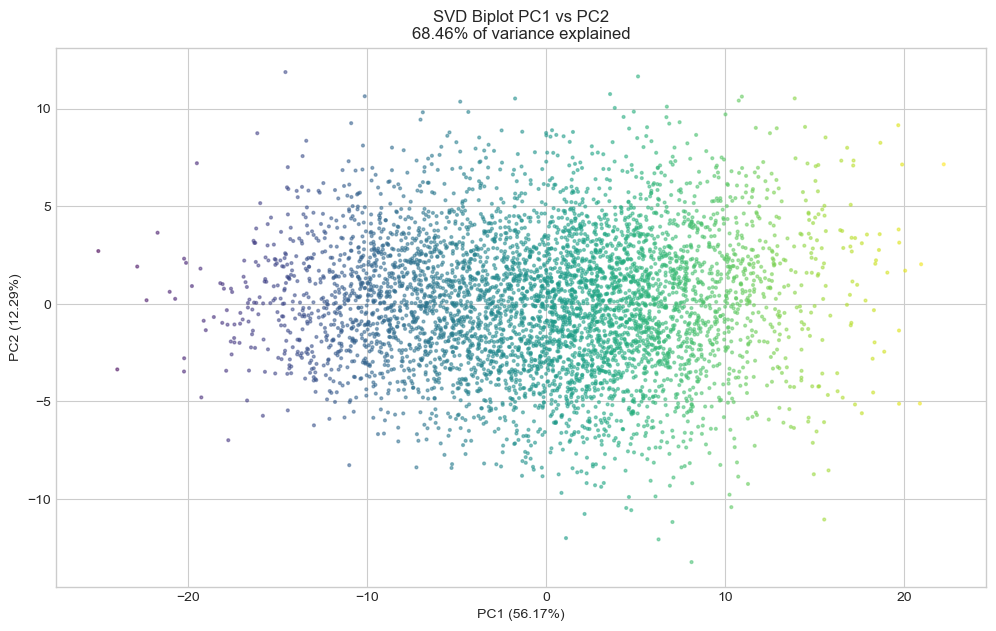

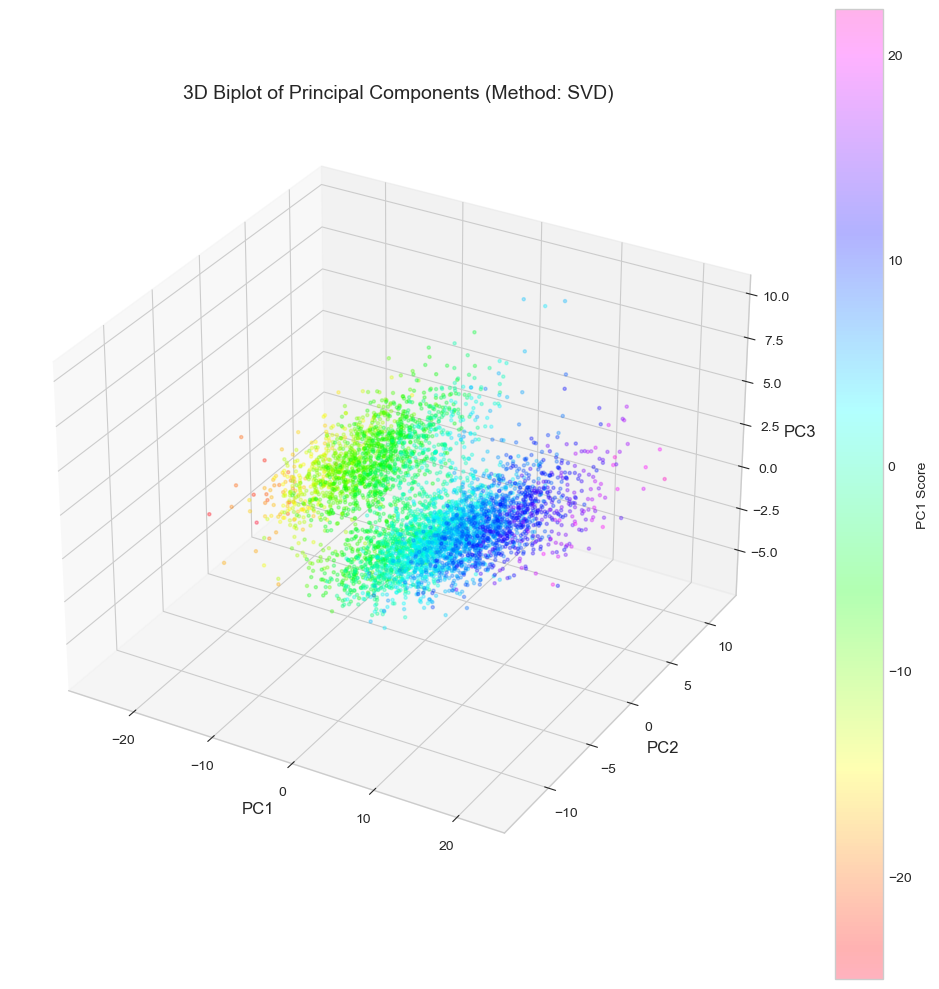

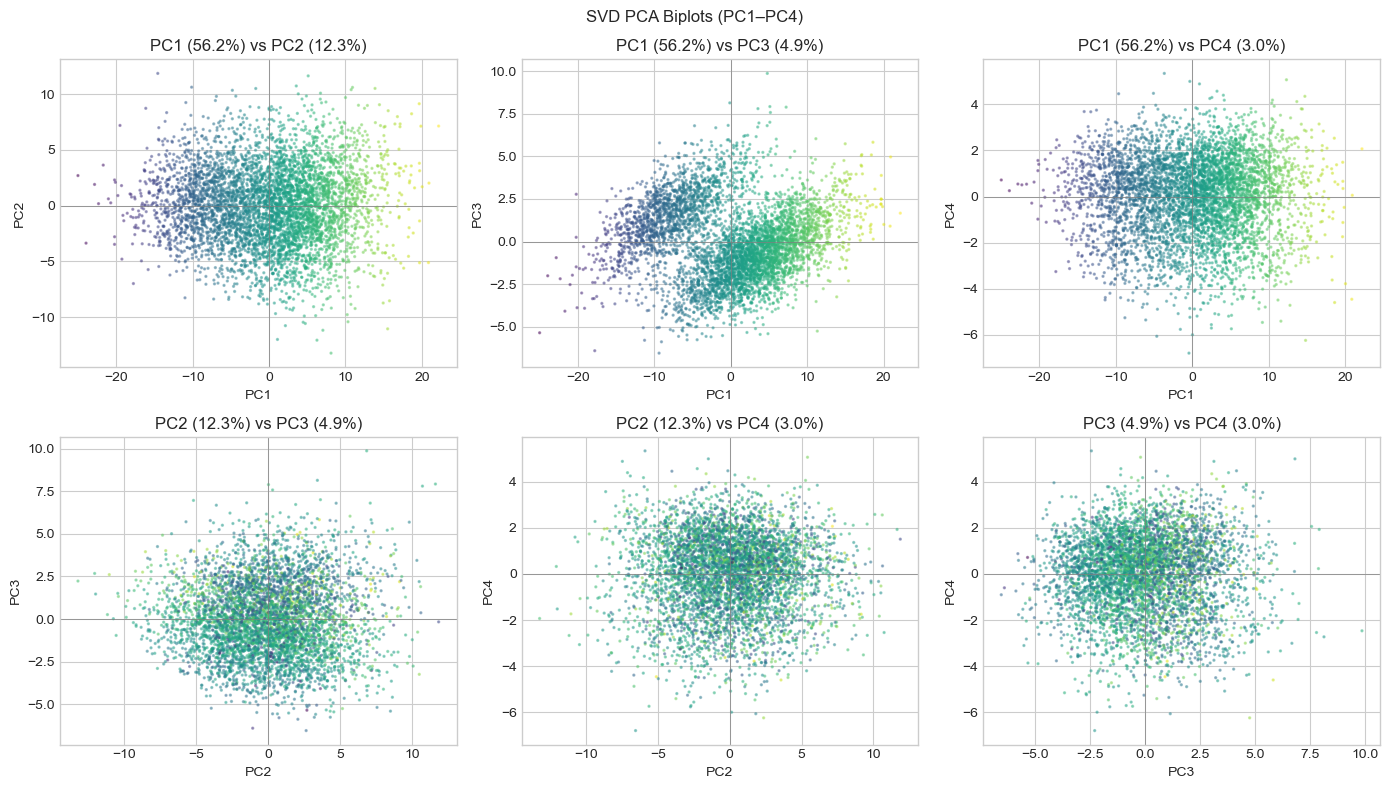

In [17]:
# Biplot for SVD
create_biplot(scores_svd, explained_variance_svd, method_name='SVD', components=(1,2))

# 3D Biplot for SVD
create_3d_biplot(scores_svd, method_name='SVD', components=(1,2,3))

# Biplot grid for SVD
multi_biplots(scores_svd, explained_variance_svd, method_name="SVD")

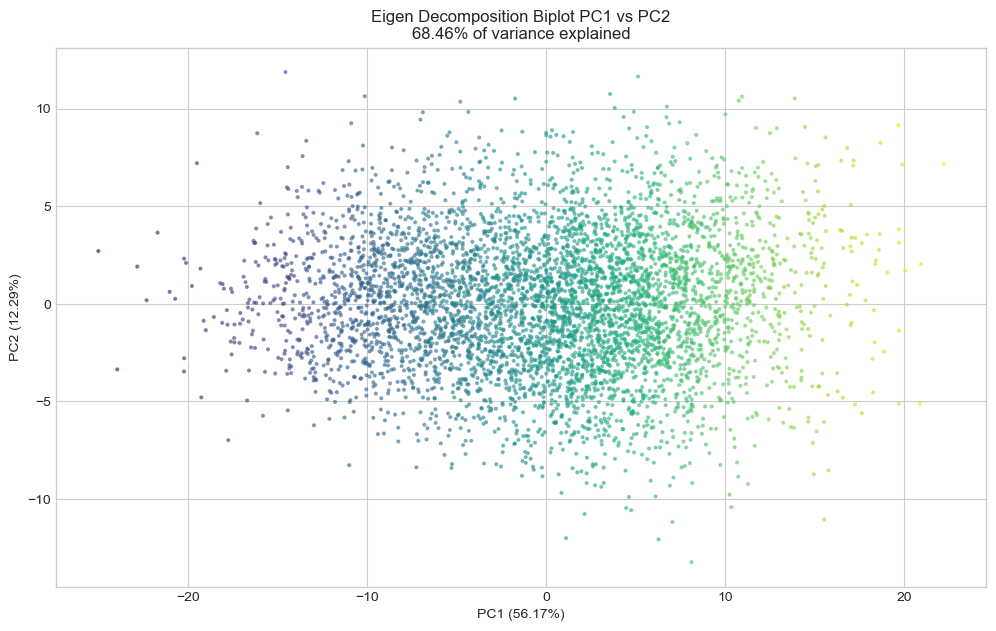

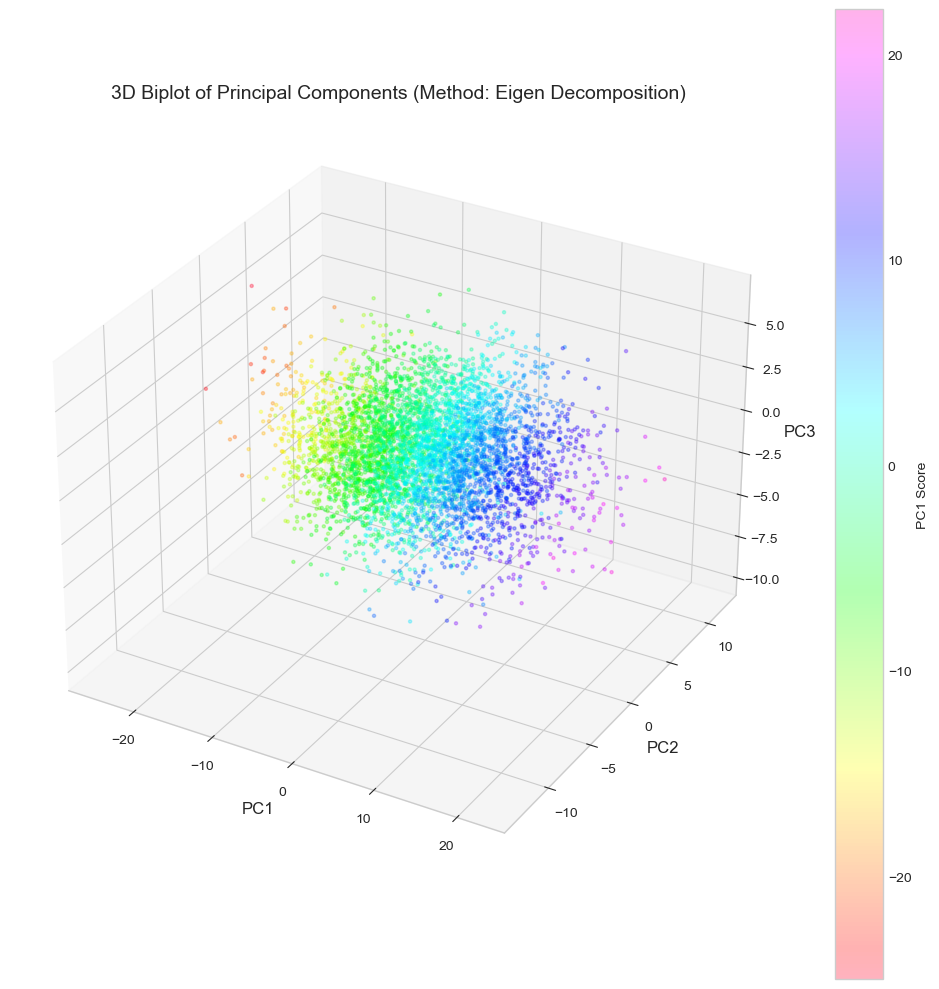

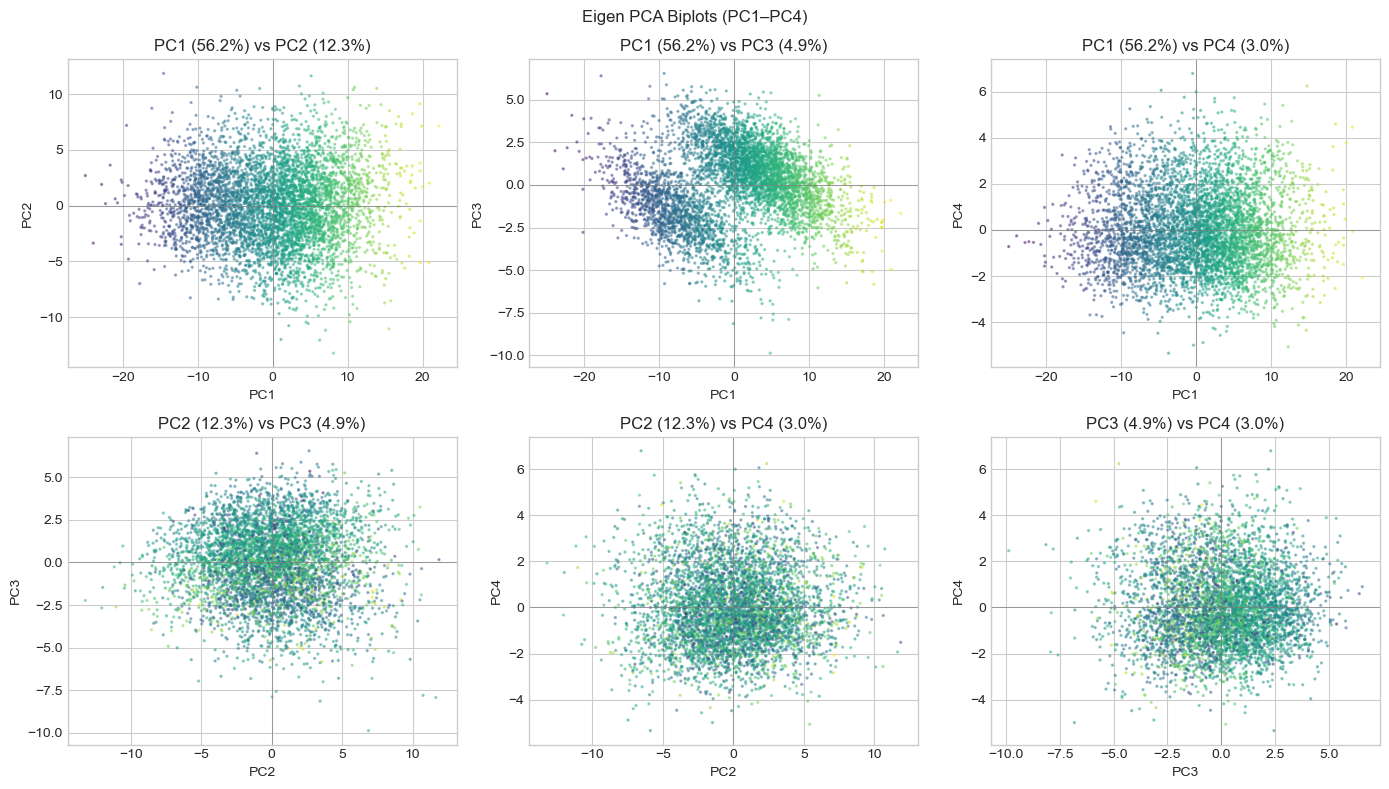

In [18]:
# Biplot for Eigen Decomposition
create_biplot(scores_eig, explained_variance_eig, method_name='Eigen Decomposition', components=(1,2))

# Biplot for Eigen Decomposition
create_3d_biplot(scores_eig, method_name='Eigen Decomposition', components=(1,2,3))

# Biplot grid for Eigen Decomposition
multi_biplots(scores_eig, explained_variance_eig, method_name="Eigen")

In [19]:
original_dims = A.shape[1]
variance_threshold = 75

# determine number of PCs needed
selected_dims_svd = np.argmax(cumulative_variance_svd >= variance_threshold) + 1
selected_dims_eig = np.argmax(cumulative_variance_eig >= variance_threshold) + 1

# add highlighting to summary tables
svd_summary["Selected"] = svd_summary["PC"] <= selected_dims_svd
eig_summary["Selected"] = eig_summary["PC"] <= selected_dims_eig

# display tables first
display(svd_summary.head(10))
display(eig_summary.head(10))

# compare methods
if selected_dims_svd == selected_dims_eig:
    selected_dims = selected_dims_svd
    print(f"Both methods agree: {selected_dims} PCs selected.")
else:
    print("Warning: SVD and Eigen PCA selected different dimensions.")
    print(f"SVD selected: {selected_dims_svd}")
    print(f"Eigen selected: {selected_dims_eig}")
    
    selected_dims = max(selected_dims_svd, selected_dims_eig)

# report variance explained
print(f"SVD: {selected_dims_svd} PCs explain {cumulative_variance_svd[selected_dims_svd-1]:.1f}% variance")
print(f"Eigen: {selected_dims_eig} PCs explain {cumulative_variance_eig[selected_dims_eig-1]:.1f}% variance")


# final dimensionality summary
variance_explained = cumulative_variance_svd[selected_dims-1]
dim_reduction = ((original_dims - selected_dims) / original_dims) * 100
variance_loss = 100 - variance_explained

print()
print(f"Therefore, {selected_dims} PCs explain {variance_explained:.1f}% of data variance.")
print(f"Reducing dimensions from {original_dims} to {selected_dims} explains {variance_explained:.1f}% of the variance.")
print(f"This results in a {dim_reduction:.1f}% reduction in dimensionality.")
print(f"The variance loss is approximately {variance_loss:.1f}%.")
print("Both SVD and Eigen decomposition produce consistent PCA results.")

,PC,Singular Value,Explained Variance (%),Cumulative Variance (%),Selected
0,1,519.235343,56.167780,56.167780,True
1,2,242.873927,12.289113,68.456893,True
2,3,153.763537,4.925672,73.382565,True
3,4,120.897874,3.045062,76.427627,True
4,5,103.723410,2.241364,78.668990,False
5,6,86.932673,1.574435,80.243426,False
6,7,81.020260,1.367559,81.610984,False
7,8,75.966289,1.202266,82.813251,False
8,9,73.164223,1.115209,83.928460,False
9,10,68.318779,0.972387,84.900846,False


,PC,Eigenvalue,Explained Variance (%),Cumulative Variance (%),Selected
0,1,53.931855,56.167780,56.167780,True
1,2,11.799909,12.289113,68.456893,True
2,3,4.729591,4.925672,73.382565,True
3,4,2.923844,3.045062,76.427627,True
4,5,2.152140,2.241364,78.668990,False
5,6,1.511760,1.574435,80.243426,False
6,7,1.313119,1.367559,81.610984,False
7,8,1.154406,1.202266,82.813251,False
8,9,1.070815,1.115209,83.928460,False
9,10,0.933678,0.972387,84.900846,False


Both methods agree: 4 PCs selected.
SVD: 4 PCs explain 76.4% variance
Eigen: 4 PCs explain 76.4% variance

Therefore, 4 PCs explain 76.4% of data variance.
Reducing dimensions from 96 to 4 explains 76.4% of the variance.
This results in a 95.8% reduction in dimensionality.
The variance loss is approximately 23.6%.
Both SVD and Eigen decomposition produce consistent PCA results.
